In [25]:
from google.colab import drive
drive.mount("/content/drive")

!pip -q install scikit-learn pandas numpy

import re
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
CLUSTER_MAP_PATH = "/content/drive/MyDrive/cluster_map.csv"
CLUSTER_POS_PATH = "/content/drive/MyDrive/cluster_to_pos.csv"

cluster_df = pd.read_csv(CLUSTER_MAP_PATH)
cluster = dict(zip(cluster_df["word"], cluster_df["cluster_id"]))

cpos_df = pd.read_csv(CLUSTER_POS_PATH)
cluster_to_pos = dict(zip(cpos_df["cluster_id"], cpos_df["majority_pos"]))

print("Loaded cluster size:", len(cluster))
print("Loaded cluster_to_pos size:", len(cluster_to_pos))
print("Sample cluster:", list(cluster.items())[:3])
print("Sample cluster_to_pos:", list(cluster_to_pos.items())[:3])


Loaded cluster size: 12405
Loaded cluster_to_pos size: 12394
Sample cluster: [('ৰচনা', 0), ('আদৰ্শৰ', 1), ('ৰাজধৰ্ম', 2)]
Sample cluster_to_pos: [(12061, 'Adj'), (873, 'N'), (3261, 'N')]


In [27]:
FILE = "/content/drive/MyDrive/all.txt"  # change if needed

try:
    with open(FILE, "r", encoding="utf-16") as f:
        text = f.read()
        print("Loaded using UTF-16.")
except UnicodeError:
    with open(FILE, "r", encoding="utf-8-sig") as f:
        text = f.read()
        print("Loaded using UTF-8-SIG.")

print("Chars:", len(text))
print(text[:200])


Loaded using UTF-16.
Chars: 421670
N - NOUN
Pr - PRONOUN
Adj - ADJECTIVE
Adv - ADVERB
V - VERB
PREP -PREPOSITION
CON - CONJUNCTION
IN - INTERJECTION

প্ৰাচীন/Adj ভাৰতৰ/N মুদ্ৰাব্যৱস্থা/N : বিনিময়ৰ/N মাধ্যম/N হিচাপে/PREP প্ৰাচীন/Adj ভাৰ


In [28]:
pattern = re.compile(r"(\S+?)/([A-Za-z]+)")

def split_sentences(text):
    chunks = re.split(r"[।\n]+", text)
    sents = []
    for ch in chunks:
        toks = pattern.findall(ch)
        if toks:
            sents.append([(w, t.upper()) for w, t in toks])
    return sents

sents = split_sentences(text)
print("Sentences:", len(sents))
print("Example:", sents[0][:20])


Sentences: 3549
Example: [('প্ৰাচীন', 'ADJ'), ('ভাৰতৰ', 'N'), ('মুদ্ৰাব্যৱস্থা', 'N'), ('বিনিময়ৰ', 'N'), ('মাধ্যম', 'N'), ('হিচাপে', 'PREP'), ('প্ৰাচীন', 'ADJ'), ('ভাৰতত', 'N'), ('মুদ্ৰা', 'N'), ('ব্যৱস্থাৰ', 'N'), ('আৰম্ভণি', 'N'), ('কেতিয়া', 'ADV'), ('হৈছিল', 'V'), ('তাক', 'PR'), ('সঠিককৈ', 'ADV'), ('কʼব', 'V'), ('নোৱাৰি', 'V')]


In [29]:
rng = np.random.default_rng(42)
idx = np.arange(len(sents))
rng.shuffle(idx)

test_frac = 0.20
n_test = int(len(sents) * test_frac)

test_sents = [sents[i] for i in idx[:n_test]]
train_sents = [sents[i] for i in idx[n_test:]]

print("Train sents:", len(train_sents))
print("Test sents :", len(test_sents))


Train sents: 2840
Test sents : 709


In [30]:
# Edit this mapping if your tagset differs
def to_coarse(tag: str) -> str:
    t = tag.upper()

    if t in {"N"}:
        return "N"
    if t in {"V"}:
        return "V"
    if t in {"ADJ", "NADJ", "VADJ"}:
        return "ADJ"
    if t in {"ADV", "ANU"}:
        return "ADV"
    if t in {"PR"}:
        return "PR"
    if t in {"CON"}:
        return "CON"
    if t in {"PREP"}:
        return "PREP"

    return "OTHER"

COARSE_TAGS = ["N","V","ADJ","ADV","PR","CON","PREP","OTHER"]
ctag2i = {t:i for i,t in enumerate(COARSE_TAGS)}
i2ctag = {i:t for t,i in ctag2i.items()}


In [31]:
cluster_pos_counts = defaultdict(Counter)

for sent in train_sents:
    for w, t in sent:
        cid = cluster.get(w, None)
        if cid is not None:
            cluster_pos_counts[cid][to_coarse(t)] += 1

cluster_conf = {}
cluster_to_coarse = {}

for cid, cnts in cluster_pos_counts.items():
    total = sum(cnts.values())
    top_tag, top_cnt = cnts.most_common(1)[0]
    cluster_conf[cid] = top_cnt / total
    cluster_to_coarse[cid] = top_tag

print("Clusters scored:", len(cluster_conf))
print("Example:", list(cluster_to_coarse.items())[:5])


Clusters scored: 10686
Example: [(2274, 'ADJ'), (10148, 'V'), (10954, 'V'), (6251, 'N'), (4741, 'V')]


In [32]:
# Small lexicons (extend anytime)
PRONOUNS = set(["মই","আমি","তই","তুমি","সেই","সি","তেওঁ","তাহাঁত","আপুনি"])
CONJ = set(["আৰু","কিন্তু","অথবা","যদি","যেতিয়া","কিয়নো","তথাপি"])
PREP = set(["লৈ","পৰা","সহ","বাবে","দ্বাৰা","সঙ্গে","তলত","ওপৰত"])

CLUSTER_PURITY_THR = 0.90  # try 0.85 / 0.90 / 0.95

def lf_cluster(w):
    cid = cluster.get(w, None)
    if cid is None:
        return None
    if cluster_conf.get(cid, 0.0) >= CLUSTER_PURITY_THR:
        return cluster_to_coarse.get(cid, None)
    return None

def lf_pronoun(w):
    return "PR" if w in PRONOUNS else None

def lf_conj(w):
    return "CON" if w in CONJ else None

def lf_prep(w):
    return "PREP" if w in PREP else None

# Light ADJ hint (optional, conservative)
def lf_adj_hint(w):
    if w.endswith("ী") or w.endswith("ীয়া"):
        return "ADJ"
    return None

# Very weak fallback ONLY for ablation (no-cluster setting)
def lf_fallback_noun(_w):
    return "N"

def build_LFS(use_cluster: bool):
    lfs = []
    if use_cluster:
        lfs.append(("cluster", lf_cluster, 3.0))  # strongest anchor

    lfs.extend([
        ("adj_hint", lf_adj_hint, 1.5),
        ("pronoun", lf_pronoun, 2.0),
        ("conj", lf_conj, 2.0),
        ("prep", lf_prep, 2.0),
    ])

    # ensure no-cluster baseline doesn't produce empty training
    if not use_cluster:
        lfs.append(("fallbackN", lf_fallback_noun, 0.2))

    return lfs


In [33]:
import numpy as np

def weak_label_distribution(w, LFS):
    scores = np.zeros(len(COARSE_TAGS), dtype=float)
    votes = 0

    for _name, lf, wt in LFS:
        out = lf(w)
        if out is None:
            continue
        if out not in ctag2i:
            continue
        scores[ctag2i[out]] += wt
        votes += 1

    if votes == 0:
        return None  # abstain

    probs = np.exp(scores - scores.max())
    probs = probs / probs.sum()
    return probs


In [34]:
def word_shape(w):
    out = []
    for ch in w:
        if ch.isdigit():
            out.append("0")
        elif ch.isalpha():
            out.append("A")
        else:
            out.append(ch)
    return "".join(out)[:12]

def make_feats(words, i):
    w = words[i]
    feats = {
        "w": w,
        "shape": word_shape(w),
        "pref1": w[:1],
        "pref2": w[:2],
        "pref3": w[:3],
        "suf1": w[-1:],
        "suf2": w[-2:],
        "suf3": w[-3:],
        "cluster_id": str(cluster.get(w, -1)),  # ok even for no-cluster LF; feature stays
        "prev_w": words[i-1] if i > 0 else "__BOS__",
        "next_w": words[i+1] if i < len(words)-1 else "__EOS__",
    }
    return feats


In [35]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score

def train_and_eval_weak_model(train_sents, test_sents, use_cluster=True, min_conf=0.55):
    LFS = build_LFS(use_cluster=use_cluster)

    def build_weak_stream(thr):
        weak_words, weak_y, weak_conf = [], [], []
        for sent in train_sents:
            for w, _t in sent:
                probs = weak_label_distribution(w, LFS)
                if probs is None:
                    continue
                conf = float(np.max(probs))
                if conf < thr:
                    continue
                weak_words.append(w)
                weak_y.append(int(np.argmax(probs)))
                weak_conf.append(conf)
        return weak_words, weak_y, weak_conf

    thr = min_conf
    weak_words, weak_y, weak_conf = build_weak_stream(thr)

    # Auto-relax if empty
    if len(weak_words) == 0:
        for thr2 in [0.50, 0.45, 0.40, 0.30]:
            weak_words, weak_y, weak_conf = build_weak_stream(thr2)
            if len(weak_words) > 0:
                thr = thr2
                break

    if len(weak_words) == 0:
        raise RuntimeError("0 weak labels even after relaxing threshold. Expand lexicons or lower purity threshold.")

    coverage = len(weak_words) / sum(len(s) for s in train_sents)
    avg_conf = float(np.mean(weak_conf)) if weak_conf else 0.0

    # Train features
    Xtr_dict = [make_feats(weak_words, i) for i in range(len(weak_words))]
    ytr = weak_y

    vec = DictVectorizer(sparse=True)
    Xtr = vec.fit_transform(Xtr_dict)

    clf = LogisticRegression(max_iter=300, n_jobs=-1, class_weight="balanced")
    clf.fit(Xtr, ytr)

    # Test
    test_words = [w for sent in test_sents for w, _ in sent]
    test_true  = [ctag2i[to_coarse(t)] for sent in test_sents for _, t in sent]

    Xte_dict = [make_feats(test_words, i) for i in range(len(test_words))]
    Xte = vec.transform(Xte_dict)

    pred = clf.predict(Xte)
    acc = accuracy_score(test_true, pred)
    w_f1 = f1_score(test_true, pred, average="weighted")

    rep = classification_report(
        [i2ctag[i] for i in test_true],
        [i2ctag[i] for i in pred],
        digits=3,
        zero_division=0
    )

    return {
        "use_cluster": use_cluster,
        "min_conf_used": thr,
        "weak_tokens": len(weak_words),
        "coverage": coverage,
        "avg_weak_conf": avg_conf,
        "acc": acc,
        "weighted_f1": w_f1,
        "vec": vec,
        "clf": clf,
        "report": rep,
    }


In [36]:
import pandas as pd

res_no_cluster   = train_and_eval_weak_model(train_sents, test_sents, use_cluster=False, min_conf=0.55)
res_with_cluster = train_and_eval_weak_model(train_sents, test_sents, use_cluster=True,  min_conf=0.55)

ablation = pd.DataFrame([
    {
        "Setting": "No cluster LF",
        "Weak tokens": res_no_cluster["weak_tokens"],
        "Coverage": res_no_cluster["coverage"],
        "Avg weak conf": res_no_cluster["avg_weak_conf"],
        "Min conf used": res_no_cluster["min_conf_used"],
        "Accuracy": res_no_cluster["acc"],
        "Weighted F1": res_no_cluster["weighted_f1"],
    },
    {
        "Setting": "With cluster LF",
        "Weak tokens": res_with_cluster["weak_tokens"],
        "Coverage": res_with_cluster["coverage"],
        "Avg weak conf": res_with_cluster["avg_weak_conf"],
        "Min conf used": res_with_cluster["min_conf_used"],
        "Accuracy": res_with_cluster["acc"],
        "Weighted F1": res_with_cluster["weighted_f1"],
    }
])

ablation


,Setting,Weak tokens,Coverage,Avg weak conf,Min conf used,Accuracy,Weighted F1
0,No cluster LF,1839,0.051724,0.505737,0.50,0.099911,0.038200
1,With cluster LF,32670,0.918884,0.750503,0.55,0.905855,0.904867


In [37]:
print("=== NO CLUSTER LF (Coarse POS) ===")
print(res_no_cluster["report"])

print("\n=== WITH CLUSTER LF (Coarse POS) ===")
print(res_with_cluster["report"])


=== NO CLUSTER LF (Coarse POS) ===
              precision    recall  f1-score   support

         ADJ      0.000     0.000     0.000      1661
         ADV      0.000     0.000     0.000       147
         CON      0.338     0.614     0.436       505
           N      0.000     0.000     0.000      4238
       OTHER      0.000     0.000     0.000         2
          PR      0.112     0.805     0.197       575
        PREP      0.032     0.740     0.062       173
           V      0.000     0.000     0.000      1717

    accuracy                          0.100      9018
   macro avg      0.060     0.270     0.087      9018
weighted avg      0.027     0.100     0.038      9018


=== WITH CLUSTER LF (Coarse POS) ===
              precision    recall  f1-score   support

         ADJ      0.830     0.834     0.832      1661
         ADV      0.689     0.571     0.625       147
         CON      0.980     0.887     0.931       505
           N      0.915     0.943     0.929      4238
     

In [38]:
def train_transition_probs(train_sents):
    K = len(COARSE_TAGS)
    counts = np.ones((K, K), dtype=float)  # add-one smoothing
    start = np.ones(K, dtype=float)

    for sent in train_sents:
        tags = [ctag2i[to_coarse(t)] for _, t in sent]
        if not tags:
            continue
        start[tags[0]] += 1
        for a, b in zip(tags[:-1], tags[1:]):
            counts[a, b] += 1

    start = start / start.sum()
    trans = counts / counts.sum(axis=1, keepdims=True)
    return start, trans

start_p, trans_p = train_transition_probs(train_sents)
print("Transition matrix:", trans_p.shape)


Transition matrix: (8, 8)


In [39]:
def viterbi_decode(emissions, start_p, trans_p):
    T, K = emissions.shape
    logE = np.log(emissions + 1e-12)
    logS = np.log(start_p + 1e-12)
    logT = np.log(trans_p + 1e-12)

    dp = np.zeros((T, K), dtype=float)
    back = np.zeros((T, K), dtype=int)

    dp[0] = logS + logE[0]

    for t in range(1, T):
        for k in range(K):
            scores = dp[t-1] + logT[:, k]
            bp = int(np.argmax(scores))
            back[t, k] = bp
            dp[t, k] = scores[bp] + logE[t, k]

    path = np.zeros(T, dtype=int)
    path[T-1] = int(np.argmax(dp[T-1]))
    for t in range(T-2, -1, -1):
        path[t] = back[t+1, path[t+1]]
    return path


In [40]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

def evaluate_with_viterbi(train_sents, test_sents, res):
    vec, clf = res["vec"], res["clf"]
    K = len(COARSE_TAGS)

    y_true_all, y_pred_all = [], []

    for sent in test_sents:
        words = [w for w, _ in sent]
        true = [ctag2i[to_coarse(t)] for _, t in sent]
        if not words:
            continue

        Xdict = [make_feats(words, i) for i in range(len(words))]
        X = vec.transform(Xdict)

        proba = clf.predict_proba(X)  # columns correspond to clf.classes_
        emissions = np.full((len(words), K), 1e-9, dtype=float)
        for col, cls in enumerate(clf.classes_):
            emissions[:, cls] = proba[:, col]
        emissions = emissions / emissions.sum(axis=1, keepdims=True)

        path = viterbi_decode(emissions, start_p, trans_p)

        y_true_all.extend(true)
        y_pred_all.extend(path.tolist())

    acc = accuracy_score(y_true_all, y_pred_all)
    wf1 = f1_score(y_true_all, y_pred_all, average="weighted")
    rep = classification_report(
        [i2ctag[i] for i in y_true_all],
        [i2ctag[i] for i in y_pred_all],
        digits=3,
        zero_division=0
    )
    return acc, wf1, rep

acc_v, wf1_v, rep_v = evaluate_with_viterbi(train_sents, test_sents, res_with_cluster)
print("WITH CLUSTER + VITERBI Accuracy:", acc_v)
print("WITH CLUSTER + VITERBI Weighted F1:", wf1_v)
print(rep_v)


WITH CLUSTER + VITERBI Accuracy: 0.8944333555111998
WITH CLUSTER + VITERBI Weighted F1: 0.8906257502523511
              precision    recall  f1-score   support

         ADJ      0.874     0.771     0.819      1661
         ADV      0.908     0.469     0.619       147
         CON      0.984     0.871     0.924       505
           N      0.867     0.972     0.916      4238
       OTHER      0.000     0.000     0.000         2
          PR      0.958     0.800     0.872       575
        PREP      0.955     0.486     0.644       173
           V      0.944     0.941     0.943      1717

    accuracy                          0.894      9018
   macro avg      0.811     0.664     0.717      9018
weighted avg      0.897     0.894     0.891      9018



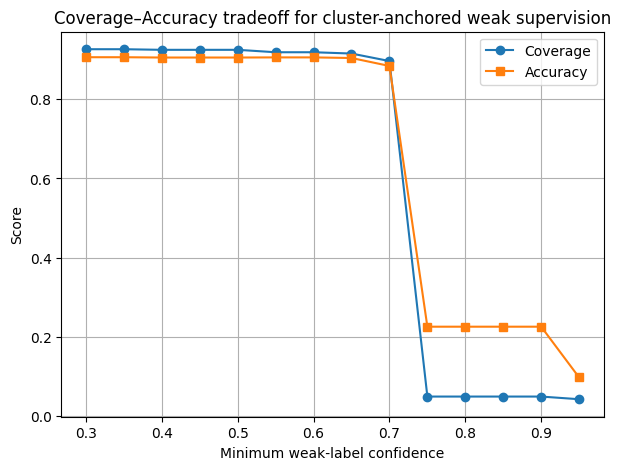

In [24]:
import numpy as np
import matplotlib.pyplot as plt

conf_vals = np.arange(0.30, 0.96, 0.05)

coverages = []
accuracies = []

for c in conf_vals:
    res = train_and_eval_weak_model(
        train_sents, test_sents,
        use_cluster=True,
        min_conf=c
    )
    coverages.append(res["coverage"])
    accuracies.append(res["acc"])

plt.figure(figsize=(7,5))
plt.plot(conf_vals, coverages, marker='o', label="Coverage")
plt.plot(conf_vals, accuracies, marker='s', label="Accuracy")
plt.xlabel("Minimum weak-label confidence")
plt.ylabel("Score")
plt.title("Coverage–Accuracy tradeoff for cluster-anchored weak supervision")
plt.legend()
plt.grid(True)
plt.show()


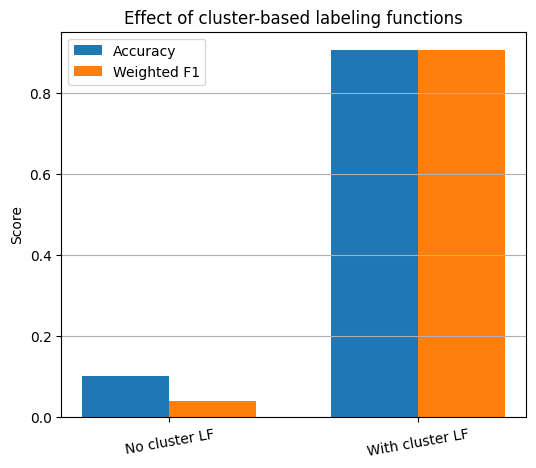

In [41]:
labels = ["No cluster LF", "With cluster LF"]
accs = [res_no_cluster["acc"], res_with_cluster["acc"]]
f1s  = [res_no_cluster["weighted_f1"], res_with_cluster["weighted_f1"]]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(6,5))
plt.bar(x - width/2, accs, width, label="Accuracy")
plt.bar(x + width/2, f1s, width, label="Weighted F1")
plt.xticks(x, labels, rotation=10)
plt.ylabel("Score")
plt.title("Effect of cluster-based labeling functions")
plt.legend()
plt.grid(axis='y')
plt.show()


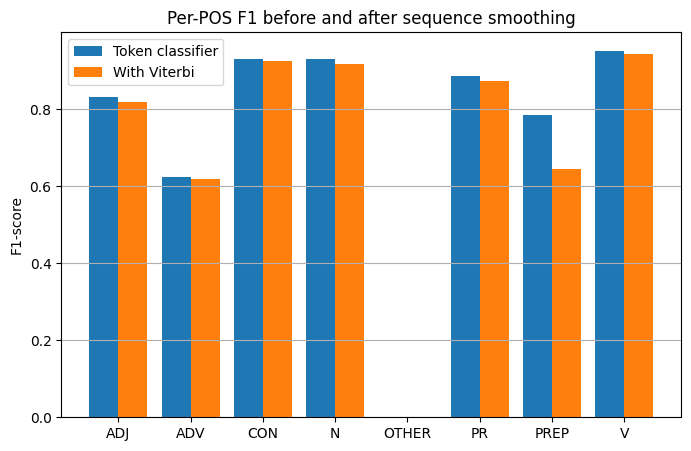

In [42]:
from sklearn.metrics import classification_report

def extract_f1(report_str):
    lines = report_str.split("\n")
    f1 = {}
    for ln in lines:
        parts = ln.split()
        if len(parts) == 5 and parts[0] in COARSE_TAGS:
            f1[parts[0]] = float(parts[3])
    return f1

f1_token = extract_f1(res_with_cluster["report"])
_, _, rep_v = evaluate_with_viterbi(train_sents, test_sents, res_with_cluster)
f1_viterbi = extract_f1(rep_v)

tags = sorted(f1_token.keys())
token_vals = [f1_token[t] for t in tags]
vit_vals   = [f1_viterbi[t] for t in tags]

x = np.arange(len(tags))
plt.figure(figsize=(8,5))
plt.bar(x-0.2, token_vals, 0.4, label="Token classifier")
plt.bar(x+0.2, vit_vals, 0.4, label="With Viterbi")
plt.xticks(x, tags)
plt.ylabel("F1-score")
plt.title("Per-POS F1 before and after sequence smoothing")
plt.legend()
plt.grid(axis='y')
plt.show()


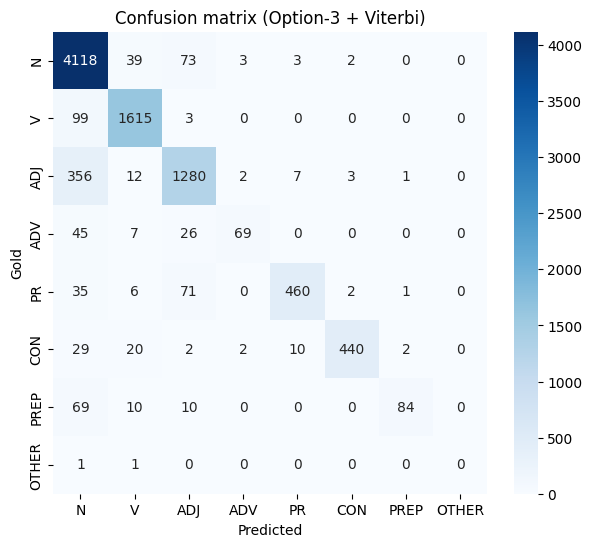

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

# reuse evaluation loop
for sent in test_sents:
    words = [w for w,_ in sent]
    true  = [ctag2i[to_coarse(t)] for _,t in sent]
    X = res_with_cluster["vec"].transform(
        [make_feats(words,i) for i in range(len(words))]
    )
    proba = res_with_cluster["clf"].predict_proba(X)

    emissions = np.zeros((len(words), len(COARSE_TAGS)))
    for j,cls in enumerate(res_with_cluster["clf"].classes_):
        emissions[:,cls] = proba[:,j]

    path = viterbi_decode(emissions, start_p, trans_p)
    y_true.extend(true)
    y_pred.extend(path)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, xticklabels=COARSE_TAGS,
            yticklabels=COARSE_TAGS,
            annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Gold")
plt.title("Confusion matrix (Option-3 + Viterbi)")
plt.show()
